<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# from cellmender.utils.visualization_utils import plot_cross_species_histogram

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k, hgmm12k, tiny_cellbender, simulation1, custom
rerun_tools = False  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False
threads = 8

# only required if dataset_name == "custom"; if using a dataset option above, then this will override the defaults filled out below
adata_path_raw_custom = None
adata_path_cellmender_custom = None
adata_path_cellbender_custom = None
soupx_out_prefix_custom = None
decontx_out_prefix_custom = None
adata_path_scar_custom = None
sequencing_technology_custom = None
model_pkl_custom = None
matrix_tar_files_dir_custom = None
raw_tar_file_dir_custom = None
filtered_tar_file_dir_custom = None
cellmender_max_iter_custom = None
cellmender_beta_custom = None
cellmender_cell_ambient_fraction_custom = None
cellbender_epochs_custom = None
cellbender_fpr_custom = None
cellbender_zdim_custom = None
cellbender_expected_cells_custom = None
scar_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
umi_top_percentile_to_remove_custom = None
fraction_doublet_custom = None
unique_genes_top_percentile_to_remove_custom = None
mt_gene_percentile_to_remove_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

cellmender_matrix_url = None
cellbender_matrix_url = None
cellbender_matrix_filtered_url = None
cellbender_ckpt_url = None
soupx_matrix_url = None
decontx_matrix_url = None
scar_matrix_url = None

cellmender_log_file = os.path.join(data_dir, "cellmender.log")
cellbender_ckpt = os.path.join(out_dir, "cellbender_ckpt.tar.gz")

if dataset_name == "tiny_cellbender":
    adata_path_raw = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    adata_path_cellmender = f"{data_dir}/tiny_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    soupx_out_prefix = None  # f"{data_dir}/tiny_output_soupx"
    decontx_out_prefix = None  # f"{data_dir}/tiny_output_decontx"
    adata_path_scar = None
    sequencing_technology = "10XV2"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(adata_path_raw):
        raise FileNotFoundError(f"Original matrix file not found: {adata_path_raw}. Create with CellBender's `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    matrix_tar_files_dir = None
    raw_tar_file_dir = None
    filtered_tar_file_dir = None

    cellmender_matrix_url = None
    cellbender_matrix_url = None
    cellbender_matrix_filtered_url = None
    cellbender_ckpt_url = None
    soupx_matrix_url = None
    decontx_matrix_url = None

    cellmender_max_iter = 10
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 2
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_expected_cells = None
    cellbender_total_droplets = None
    scar_epochs = 2
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    umi_top_percentile_to_remove = None
    fraction_doublet = None
    unique_genes_top_percentile_to_remove = None
    mt_gene_percentile_to_remove = None
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/pbmc8k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/pbmc8k_output_soupx"
    decontx_out_prefix = f"{data_dir}/pbmc8k_output_decontx"
    adata_path_scar = f"{data_dir}/pbmc8k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir) and rerun_tools:
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellmender_matrix_url = "https://caltech.box.com/shared/static/dltpt6ixhvzg0rb6h1058aamrcmi7oy7.h5ad"
    cellbender_matrix_url = "https://caltech.box.com/shared/static/trxd26eqmr33cg3ot0l3jins9s193ob6.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/bnilabzuvdvtm1knpsfgy89php938qft.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/hj41un9dz0pk5j10t8dyfj2mbllzrp6s.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/7lhpw8bgwf3b3gyl7wgqe15h3yhxamld.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/zzfs06lp634g2rhuuph200rvga08atzh.gz"
    scar_matrix_url = "https://caltech.box.com/shared/static/jhg1yd0kaao0atsyzs1yfne25dkqwz4f.h5ad"
    
    cellmender_max_iter = 500
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_expected_cells = None
    cellbender_total_droplets = None
    scar_epochs = 200
    expected_cells = 8381
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 5
    fraction_doublet = 0.15
    unique_genes_top_percentile_to_remove = 5
    mt_gene_percentile_to_remove = 10
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = {
        "Monocytes/neutrophils": ["S100A8", "S100A9", "S100A12", "FCGR3A"],
        "Monocytes/pDCs": ["LYZ", "CST3", "FCN1", "LILRA4"],
        "T": ["IL32", "TRAC", "CCR7", "FOXP3", "CD8A", "CD8B", "NKG7", "GNLY", "TRGC1", "SLC4A10"],
        "B": ["IGHD", "CD79A", "FCER2", "TNFRSF13B"],
        "NK": ["KLRF1", "SPON2"],
        "Progenitor": ["PPBP"],
        "Baso./neutro./progenitor": ["SDPR", "CLU"],
        "(Broad expression)": ["PTPRC"]
    }
elif dataset_name == "hgmm12k":
    adata_path_raw = f"{data_dir}/hgmm_12k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/hgmm_12k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/hgmm_12k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/hgmm_12k_output_soupx"
    decontx_out_prefix = f"{data_dir}/hgmm_12k_output_decontx"
    adata_path_scar = f"{data_dir}/hgmm_12k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = None

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "hg19")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "hg19")
    if not os.path.exists(raw_tar_file_dir) and rerun_tools:
        raw_tar_path = os.path.join(matrix_tar_files_dir, "hgmm_12k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "hgmm_12k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellmender_matrix_url = "https://caltech.box.com/shared/static/asrt7vgt7lnhazcjujkil1ak1v9y6qo5.h5ad"
    cellbender_matrix_url = "https://caltech.box.com/shared/static/p3v6ader1i27jcj5xhwfcmg1w8dkp158.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/0dma5qrc94tbi07pic0w8c0b50jxmach.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/esz6du1ti0wakqc1j2y1gzg445zllcw5.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/mt9us648ol61hdol3mohrpg1t658quqv.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/2hrjra6dcw92om90wgz4vwbkcebtt5r8.gz"
    scar_matrix_url = "https://caltech.box.com/shared/static/8m3zmvqajy4tpui5c2jhxjr8q6pfoqg7.h5ad"
    
    cellmender_max_iter = 500
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_total_droplets = None
    scar_epochs = 200
    expected_cells = 12820
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 0
    fraction_doublet = None
    unique_genes_top_percentile_to_remove = 0
    mt_gene_percentile_to_remove = 0
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = None

    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, show=False)
    adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir = matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix
    #!!! continue filling out

# elif dataset_name == "simulation1":
#     if not os.path.exists(adata_path_raw):
#         adata = cm_utils.simulate_cells(adata_path_raw, ...)
    
#     paths = cm_utils.write_10x_like(adata, matrix_tar_files_dir)

#     # # soupx inputs
#     # matrix_tar_files_dir = matrix_tar_files_dir
#     adata_soupx_obs_csv = paths["celltypes"]
#     # soupx_out_prefix

#     # # decontx inputs
#     raw_tar_file_dir = paths["raw"]
#     filtered_tar_file_dir = paths["filtered"]
#     sequencing_technology = paths["technology"]
#     # decontx_out_prefix
#     #!!! continue filling out

# set any custom variables provided by the user
for var in ["adata_path_raw", "adata_path_cellmender", "adata_path_cellbender", "soupx_out_prefix", "decontx_out_prefix", "sequencing_technology", "model_pkl", "matrix_tar_files_dir", "raw_tar_file_dir", "filtered_tar_file_dir", "cellmender_max_iter", "cellmender_beta", "cellmender_cell_ambient_fraction", "cellbender_epochs", "cellbender_fpr", "cellbender_expected_cells", "cellbender_zdim", "cellbender_total_droplets", "scar_epochs", "expected_cells", "cs_empty_threshold", "min_genes", "min_cells", "umi_top_percentile_to_remove", "fraction_doublet","unique_genes_top_percentile_to_remove", "mt_gene_percentile_to_remove", "max_mt_percentage", "n_top_genes", "n_pcs", "n_neighbors", "leiden_resolution", "marker_genes"]:
    custom = globals().get(f"{var}_custom")
    if custom is not None:
        globals()[var] = custom

adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")

## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

12:34:18 - INFO - Loading adata from '/data/cellmender/notebooks/data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (8381): 1386.00


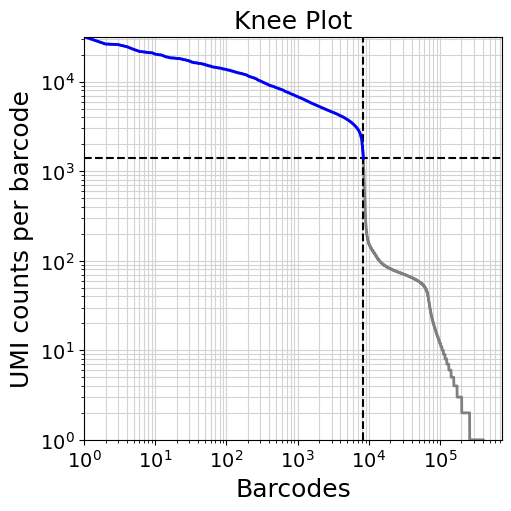

In [6]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [8]:
if dataset_name == "hgmm12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cm_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=0.15, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

MALAT1: 219203.0
B2M: 106492.0
TMSB4X: 102342.0
EEF1A1: 69831.0
RPS27: 62948.0
RPL21: 57949.0
RPL13: 53520.0
RPL13A: 50325.0
RPL10: 49660.0
RPS18: 44868.0


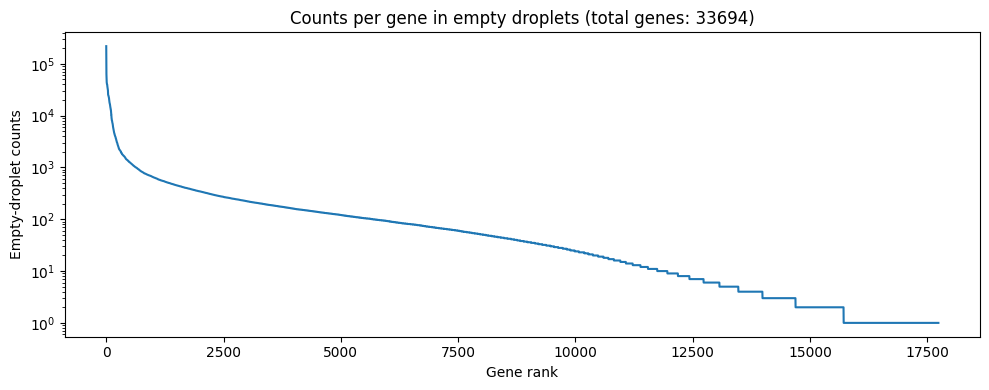

In [9]:
cm_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cm_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## cellmender

In [10]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    if rerun_tools:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, threads=threads, verbose=verbose, log_file=cellmender_log_file)
    else:
        !wget -O {adata_path_cellmender} {cellmender_matrix_url}

CPU times: user 19 μs, sys: 1 μs, total: 20 μs
Wall time: 23.1 μs


In [11]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

Counts are less than or equal check for CellMender: True


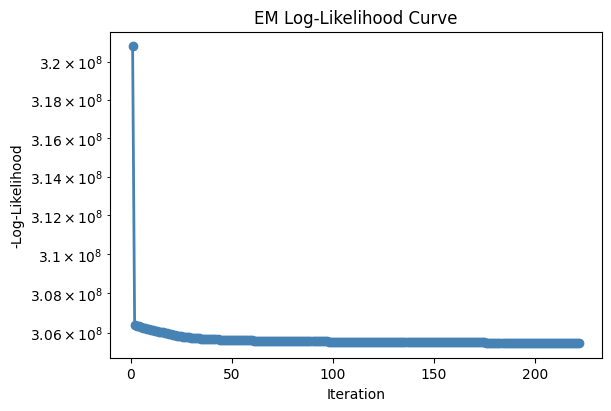

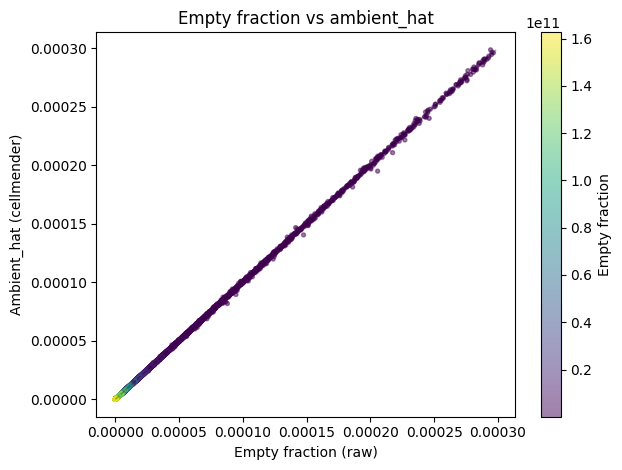

In [12]:
# plot CellMender likelihood over epochs
cm_utils.plot_cellmender_likelihood_over_epochs(log_path=cellmender_log_file, show=True)

# plot ambient_hat vs empty fraction
cm_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellmender, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellmender_ambient_hat_vs_empty_fraction.png"))

# # plot knee plot colored by alpha_hat
# adata = adata_raw.copy()
# adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=cellbender_total_droplets, verbose=verbose)
# adata_denoised = denoise_count_matrix(adata, adata_out=None, max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, verbose=verbose)
# adata_denoised.layers["denoised"] = adata_denoised.X.copy()
# adata_denoised.X = adata_denoised.layers["raw"].copy()
# cm_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
# cm_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
# adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
# adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
# adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

## CellBender (v0.3.0)

In [13]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = os.path.join(data_dir, "cellbender_ckpt.tar.gz").replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 552 μs, sys: 30 μs, total: 582 μs
Wall time: 422 μs


In [14]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [15]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

CPU times: user 161 μs, sys: 10 μs, total: 171 μs
Wall time: 120 μs


In [16]:
adata_soupx = cm_utils.load_adata(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [17]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 138 μs, sys: 10 μs, total: 148 μs
Wall time: 111 μs


In [18]:
adata_decontx = cm_utils.load_adata(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [19]:
%%time
%env MPLBACKEND=
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_tools:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

env: MPLBACKEND=
CPU times: user 231 μs, sys: 18 μs, total: 249 μs
Wall time: 236 μs


In [20]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for scAR: False


# Analysis

In [21]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellmender=adata_cellmender,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    print(f"{key}:\n{adata}\n\n")

raw:
AnnData object with n_obs × n_vars = 737280 × 33694
    obs: 'is_empty'
    var: 'gene_ids', 'empty_counts', 'empty_fraction'


cellmender:
AnnData object with n_obs × n_vars = 8381 × 33694
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'empty_counts', 'ambient_fraction', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'raw'


cellbender:
AnnData object with n_obs × n_vars = 8962 × 33694
    var: 'gene_ids', 'feature_types', 'genome'


soupx:
AnnData object with n_obs × n_vars = 8381 × 33694


decontx:
AnnData object with n_obs × n_vars = 8381 × 33694


scar:
AnnData object with n_obs × n_vars = 8381 × 33694
    var: 'gene_ids', 'feature_types'
    uns: 'ambient_profile_Gene Expression', 'ambient_profile_all'
    layers: 'raw'




## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sty

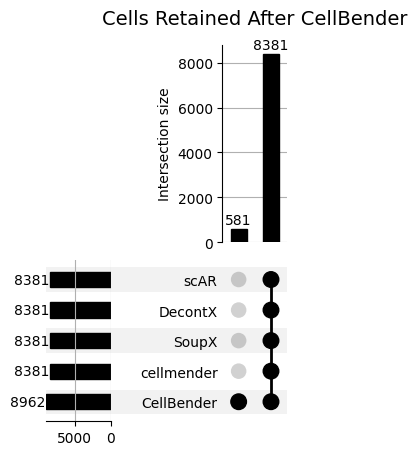

In [22]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


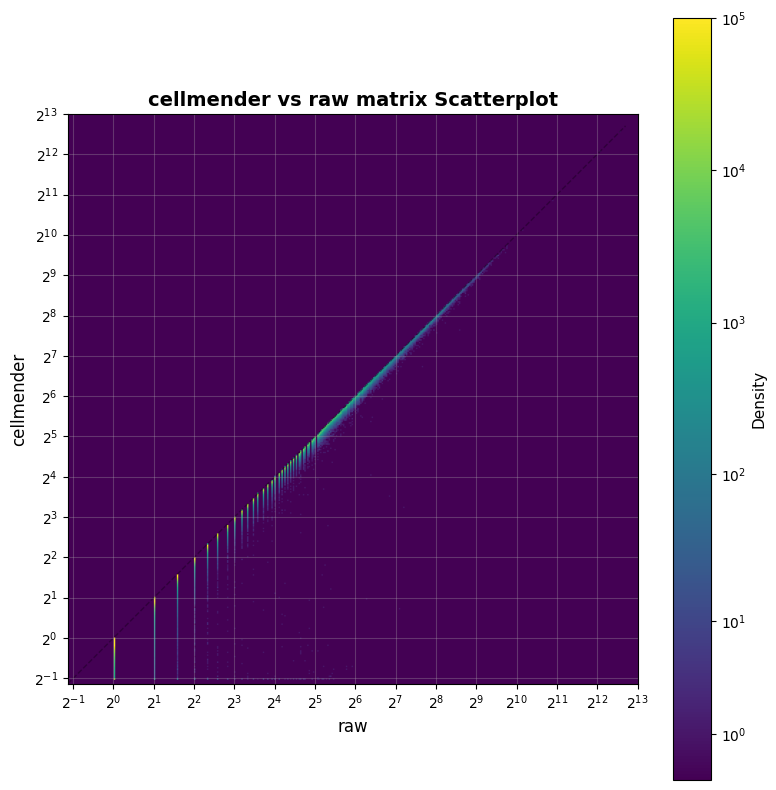

Creating scatterplot...
Calculating scatterplot...


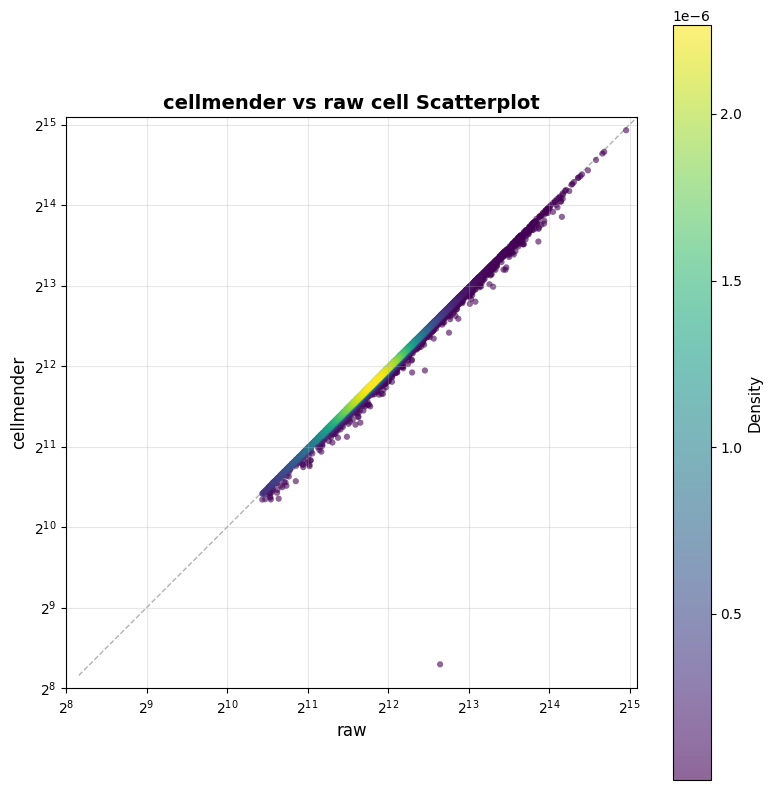

Creating scatterplot...
Calculating scatterplot...


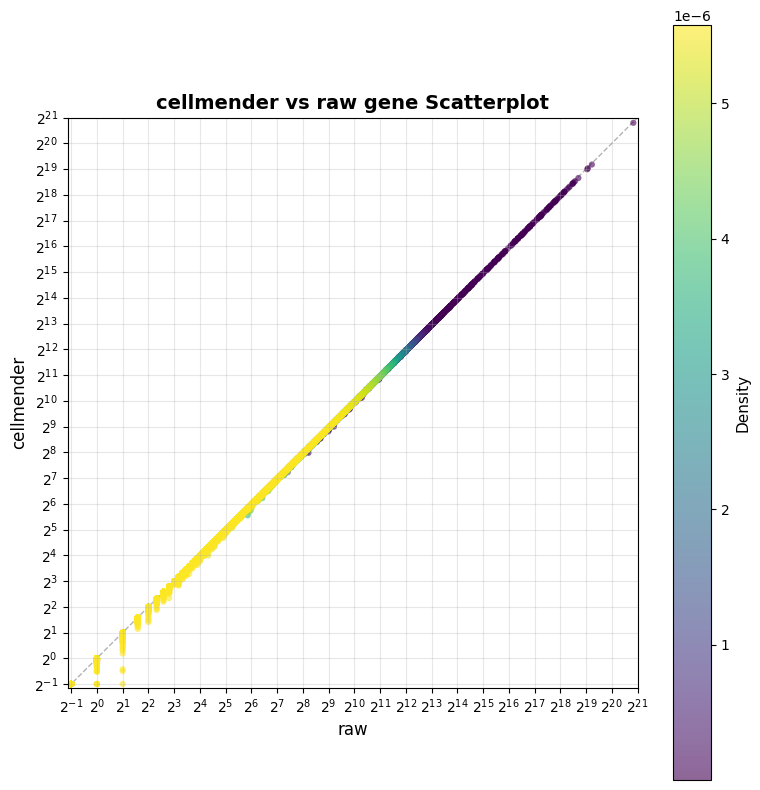

Total differences between raw and cellmender: 1,249,290.169557327


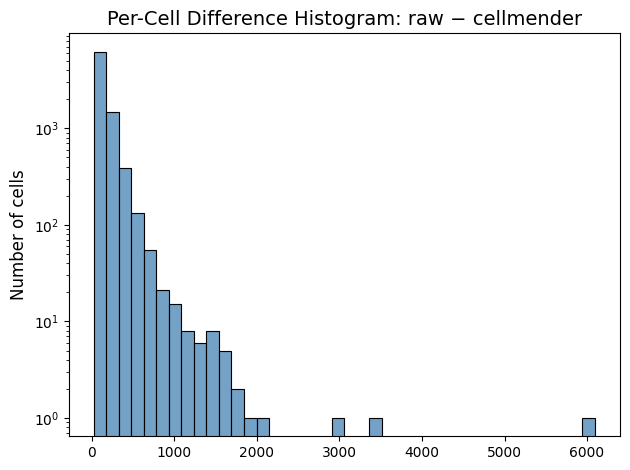

Total differences between raw and cellmender: 1,249,290.169557327


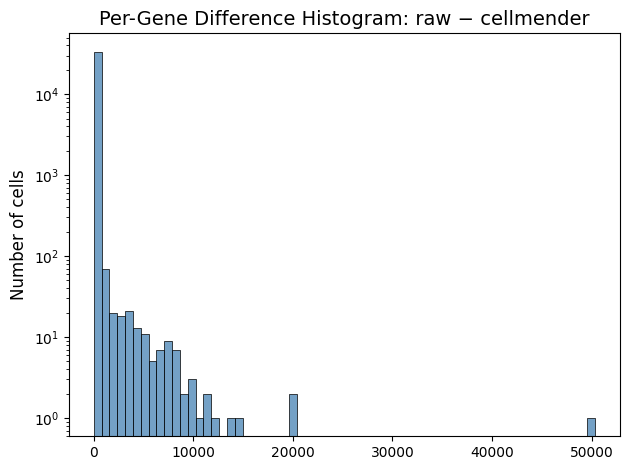

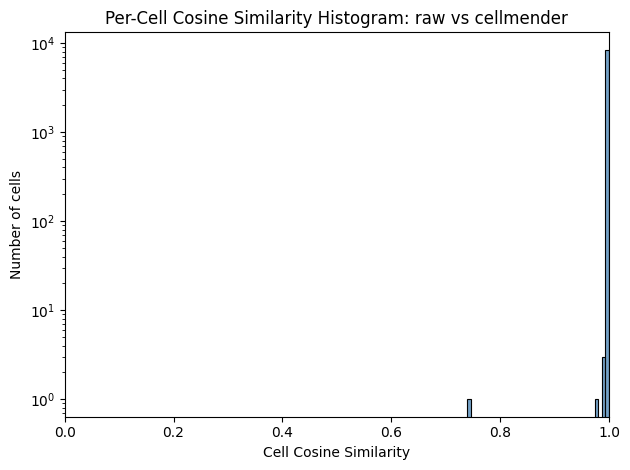

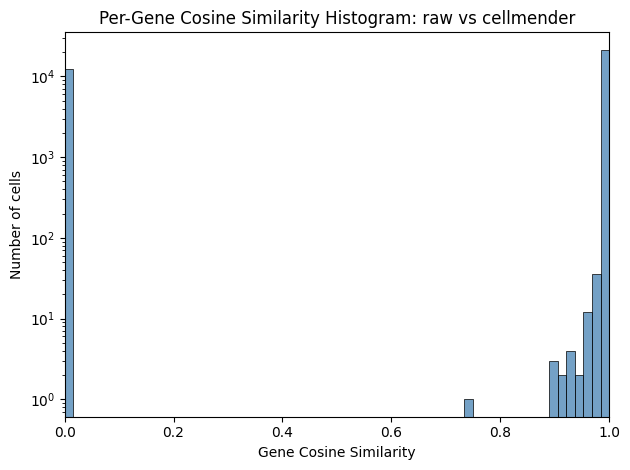

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


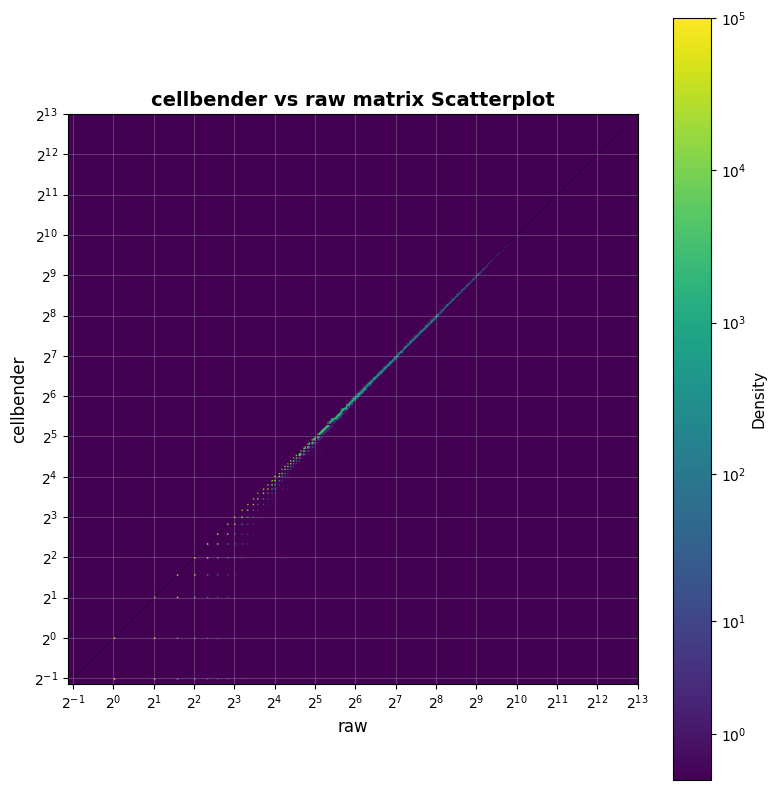

Creating scatterplot...
Calculating scatterplot...


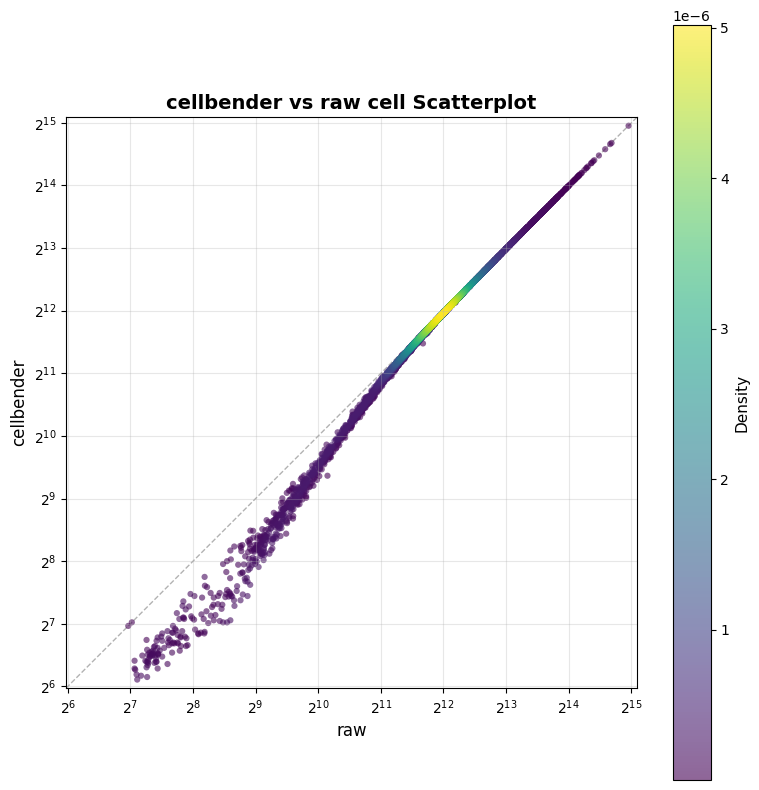

Creating scatterplot...
Calculating scatterplot...


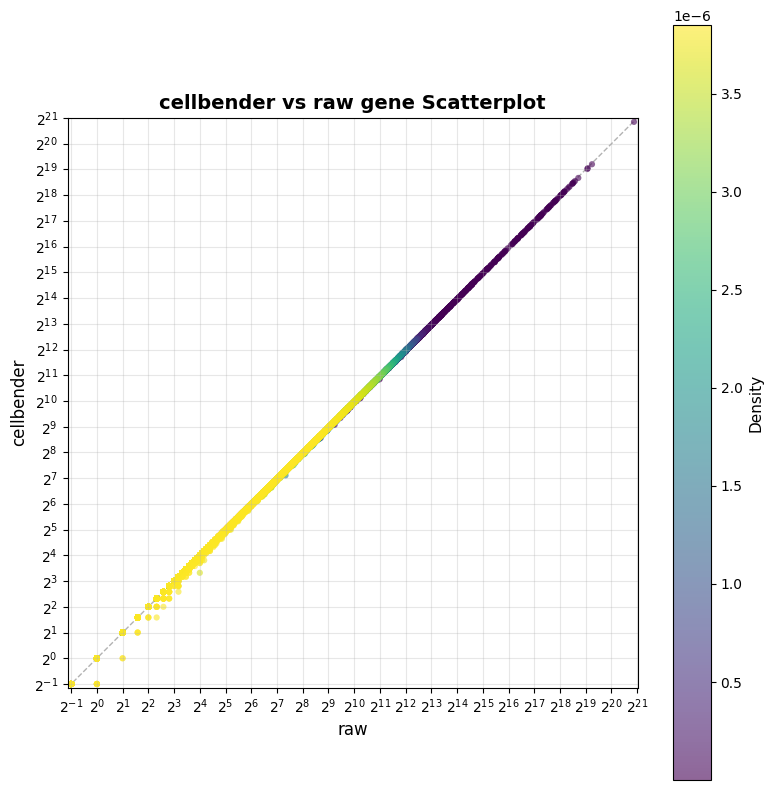

Total differences between raw and cellbender: 1,072,931.0


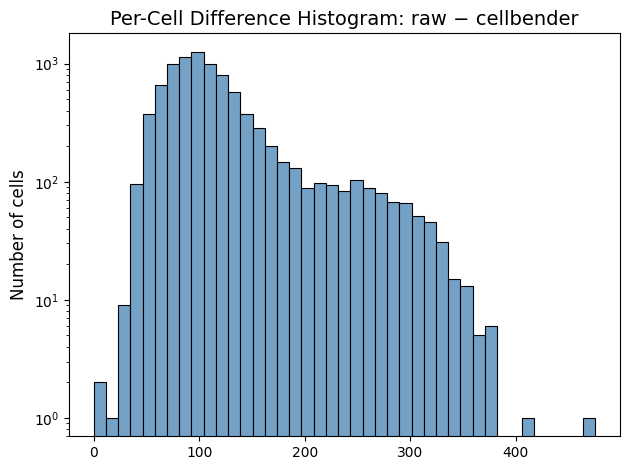

Total differences between raw and cellbender: 1,072,931.0


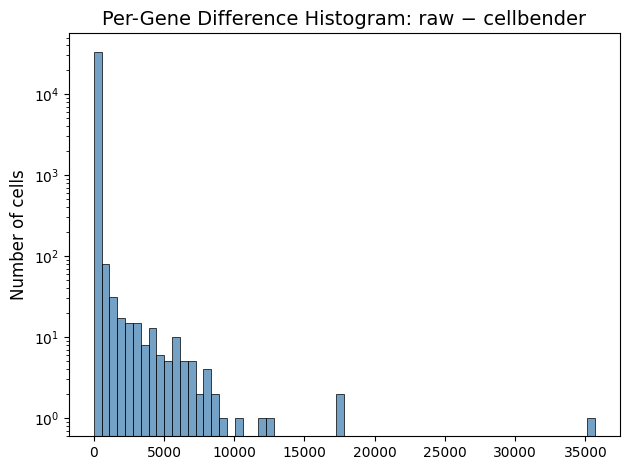

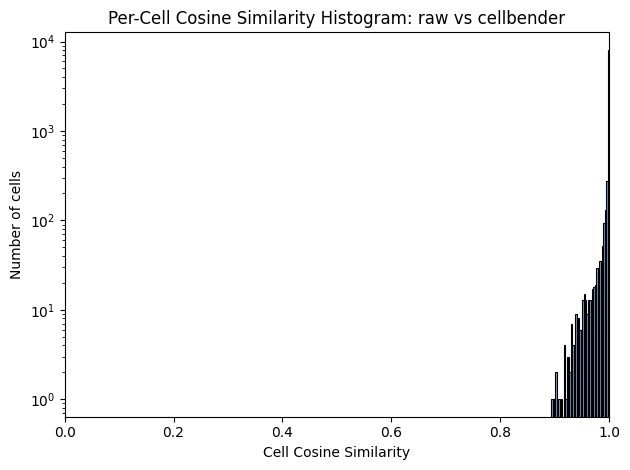

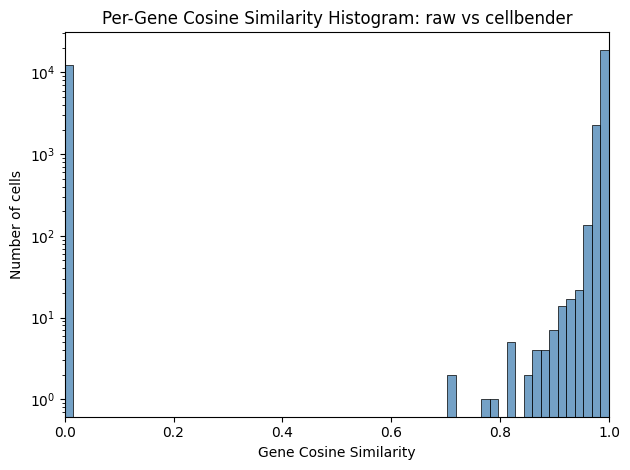

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between raw and soupx: 2,643,782.444551751
Total differences between raw and soupx: 2,643,782.444551751
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between raw and decontx: 6,456,046.266939605
Total differences between raw and decontx: 6,456,046.266939605
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


...

Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between cellmender and cellbender: -312,142.16955732676
Total differences between cellmender and cellbender: -312,142.16955732676
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...
Total differences between cellmender and soupx: 1,394,513.9087577704
Total differences between cellmender and soupx: 1,394,513.9087577704
Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


Creating scatterplot...
Calculating scatterplot...
Creating scatterplot...
Calculating scatterplot...


In [ ]:
num_iterations = len(adata_dict) * (len(adata_dict) - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellmender", "cellbender"} and key2 in {"raw", "cellmender", "cellbender"})
    # Scatterplot by matrix, cell, and gene
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cm_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # Histogram of differences from raw by matrix, cell, and gene
    # cm_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    cm_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # Histogram of cosine similarity by cell and gene
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    cm_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)

## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

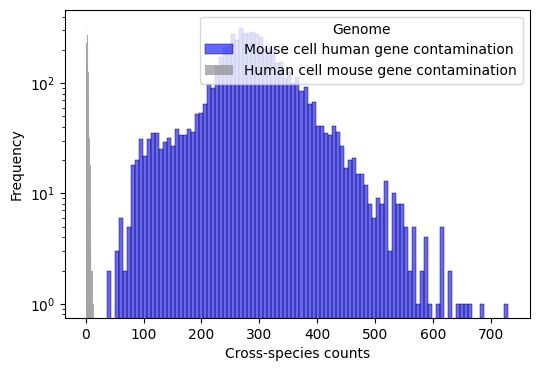

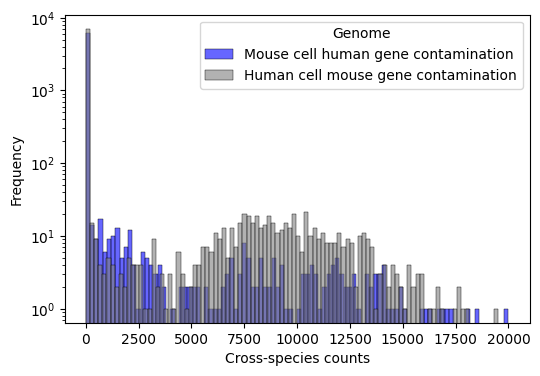

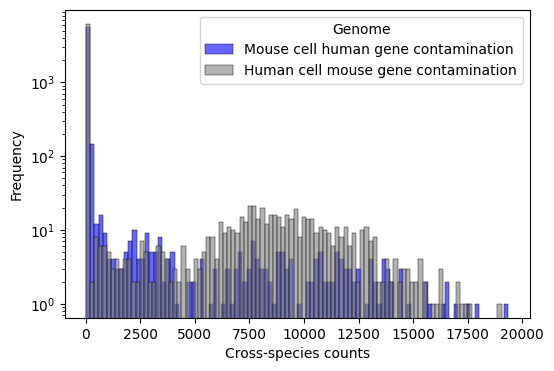

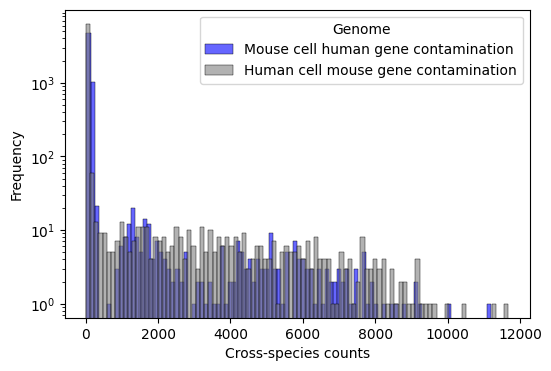

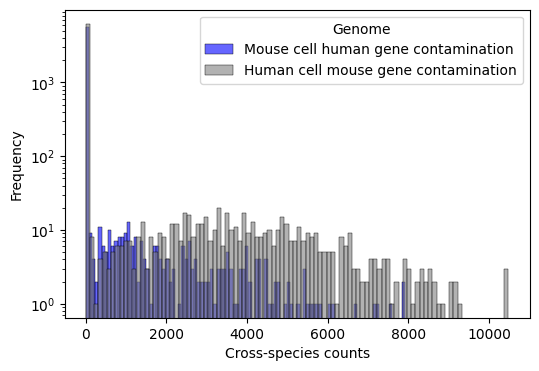

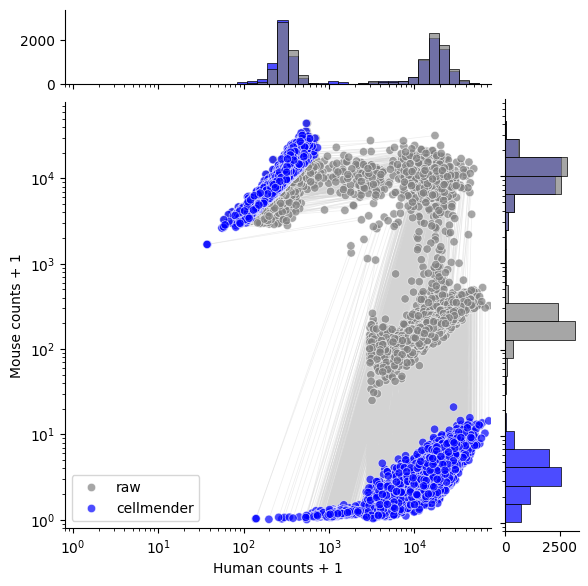

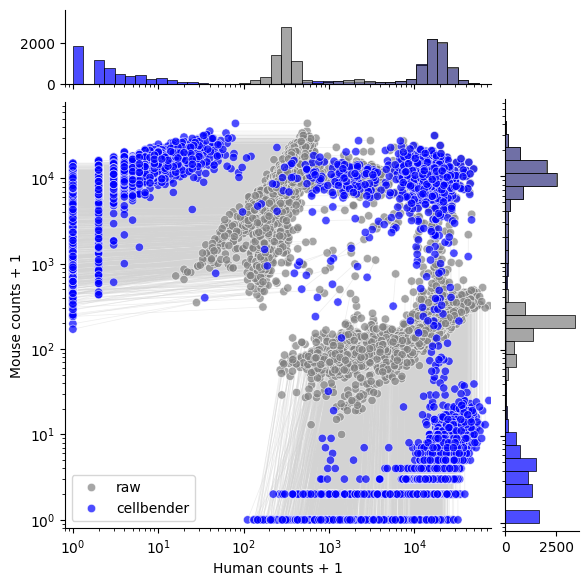

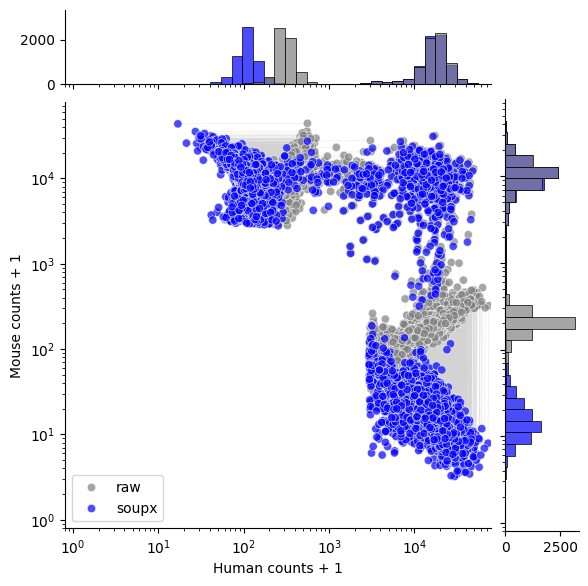

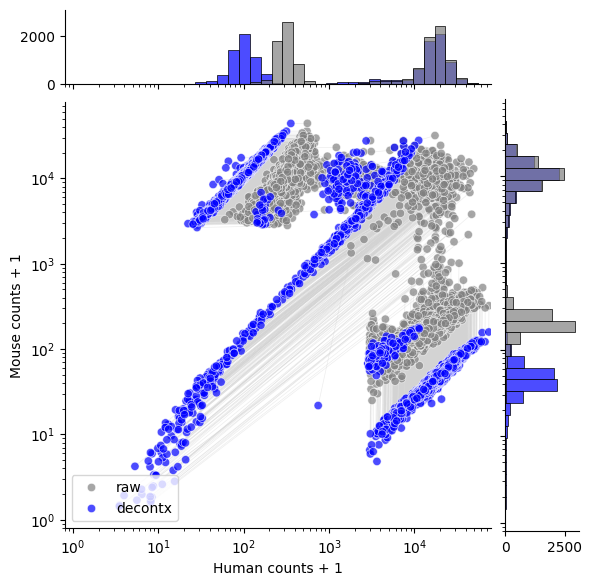

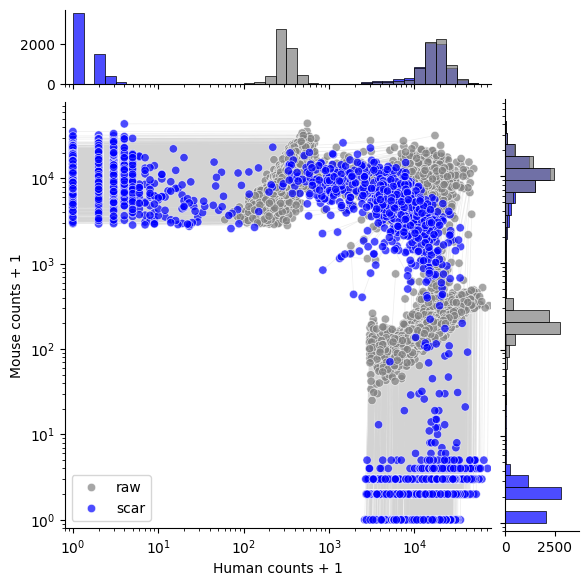

In [ ]:
if dataset_name == "hgmm12k":
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cm_utils.identify_human_and_mouse_cells(adata_raw)
    if "genome" not in adata_cellmender.obs.columns:
        adata_cellmender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellmender.obs_names)
    if "genome" not in adata_cellbender.obs.columns:
        adata_cellbender.obs["genome"] = adata_raw.obs["genome"].reindex(adata_cellbender.obs_names)
    if adata_soupx is not None and "genome" not in adata_soupx.obs.columns:
        adata_soupx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_soupx.obs_names)
    if adata_decontx is not None and "genome" not in adata_decontx.obs.columns:
        adata_decontx.obs["genome"] = adata_raw.obs["genome"].reindex(adata_decontx.obs_names)
    if adata_scar is not None and "genome" not in adata_scar.obs.columns:
        adata_scar.obs["genome"] = adata_raw.obs["genome"].reindex(adata_scar.obs_names)
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()
    for key, adata_processed in adata_dict.items():
        if key == "raw":
            continue
        cm_utils.plot_cross_species_histogram(adata_processed, processed_name=key, doublet_cell_set=doublet_cell_set, out_path_human=os.path.join(out_dir, f"{key}_human_counts_histogram.png"), out_path_mouse=os.path.join(out_dir, f"{key}_mouse_counts_histogram.png"))
        cm_utils.plot_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm12k":
    sys.exit()

## stop here for tiny dataset

In [ ]:
# if dataset_name == "tiny_cellbender":
#     sys.exit()

## Alluvial plot of cluster differences

In [ ]:
adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

In [ ]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    wompwomp_leiden_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_cluster.png")))

    wompwomp_celltype_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    display(Image(filename=os.path.join(out_dir, "alluvial_celltype.png")))
except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

Error generating alluvial plots with wompwomp: wompwomp_path /home/jrich/Desktop/wompwomp does not exist.


## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

## 0 out counts below 0.5

In [ ]:
adata_cellmender = cm_utils.zero_out_low_counts(adata_cellmender, threshold=0.5)
adata_cellbender = cm_utils.zero_out_low_counts(adata_cellbender, threshold=0.5)
if adata_soupx:
    adata_soupx = cm_utils.zero_out_low_counts(adata_soupx, threshold=0.5)
if adata_decontx:
    adata_decontx = cm_utils.zero_out_low_counts(adata_decontx, threshold=0.5)
if adata_scar:
    adata_scar = cm_utils.zero_out_low_counts(adata_scar, threshold=0.5)

In [ ]:
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
# cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
# if adata_soupx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
# if adata_decontx:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
# if adata_scar:
#     cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Standardize clusters to CellBender

... storing 'broad_celltype' as categorical


CellMender Raw Data Dotplot


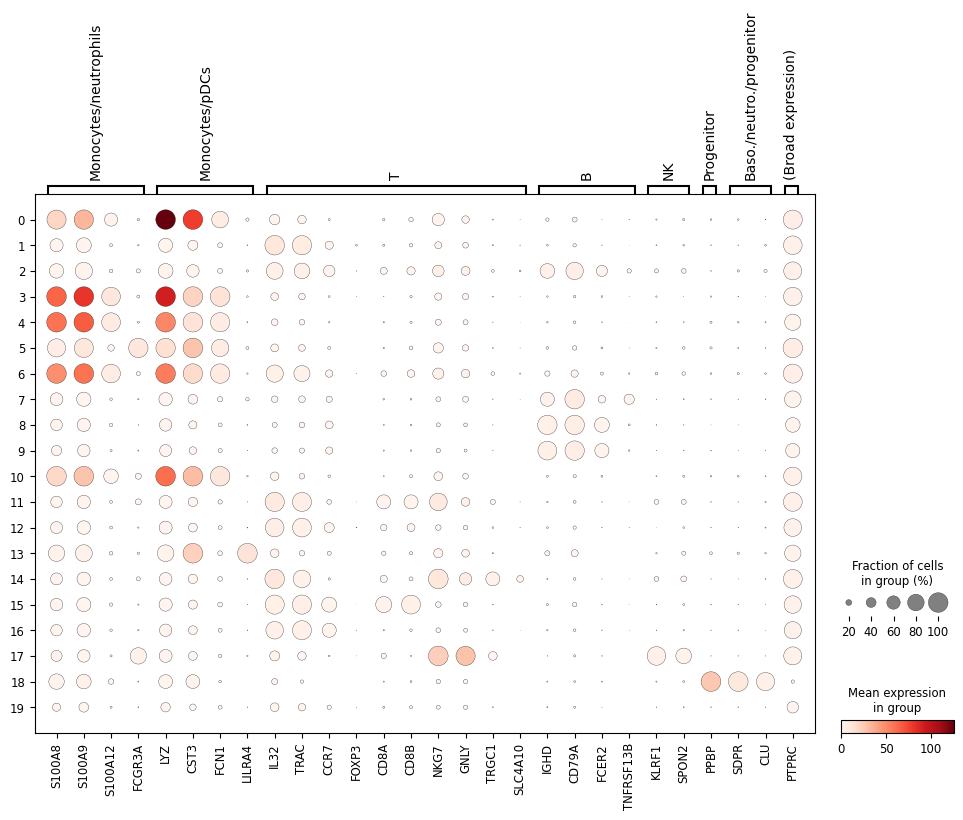

... storing 'broad_celltype' as categorical


------------------------------
CellMender Processed Data Dotplot


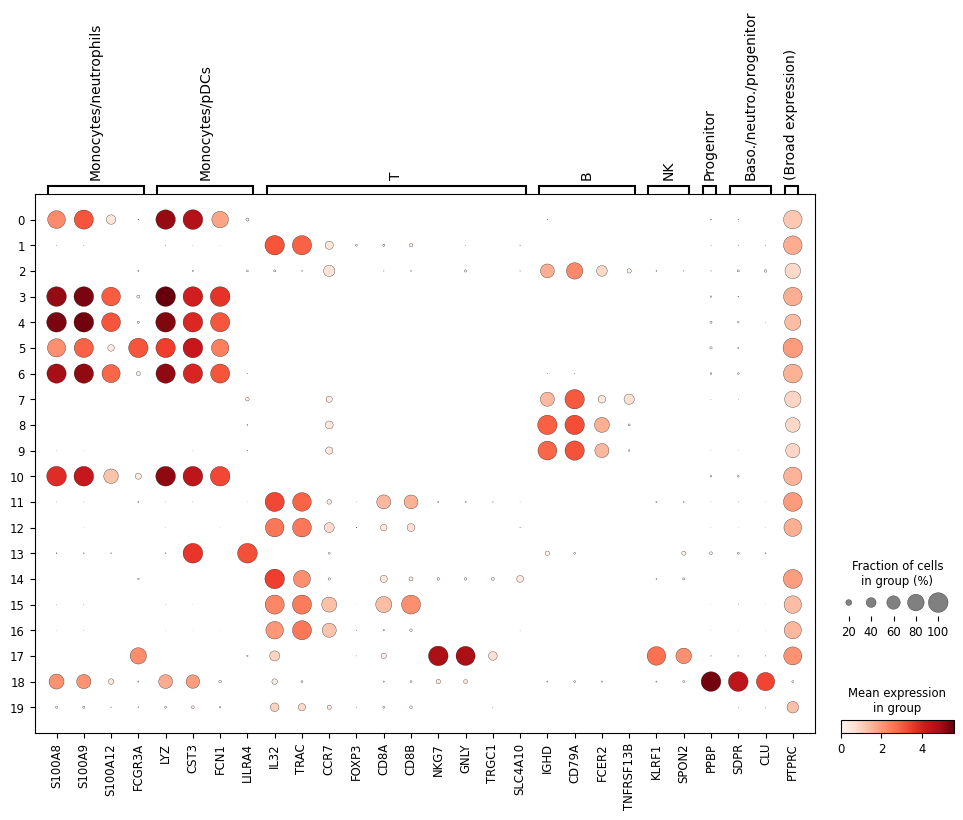

... storing 'broad_celltype' as categorical


------------------------------
SoupX Raw Data Dotplot


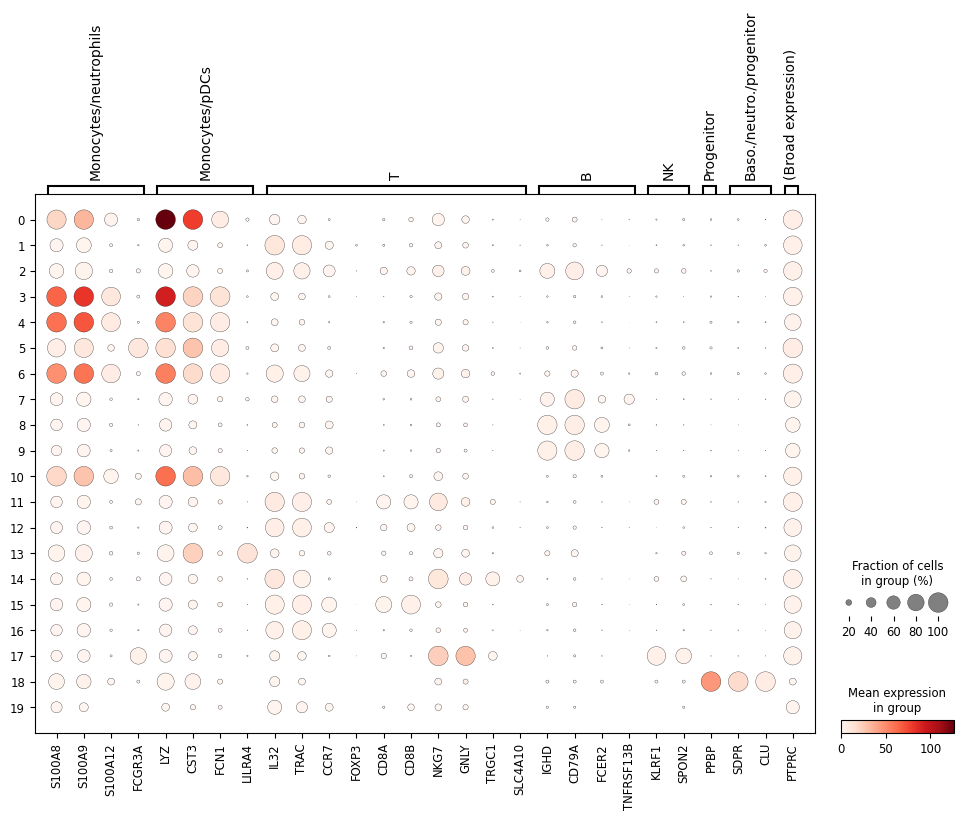

... storing 'broad_celltype' as categorical


------------------------------
SoupX Processed Data Dotplot


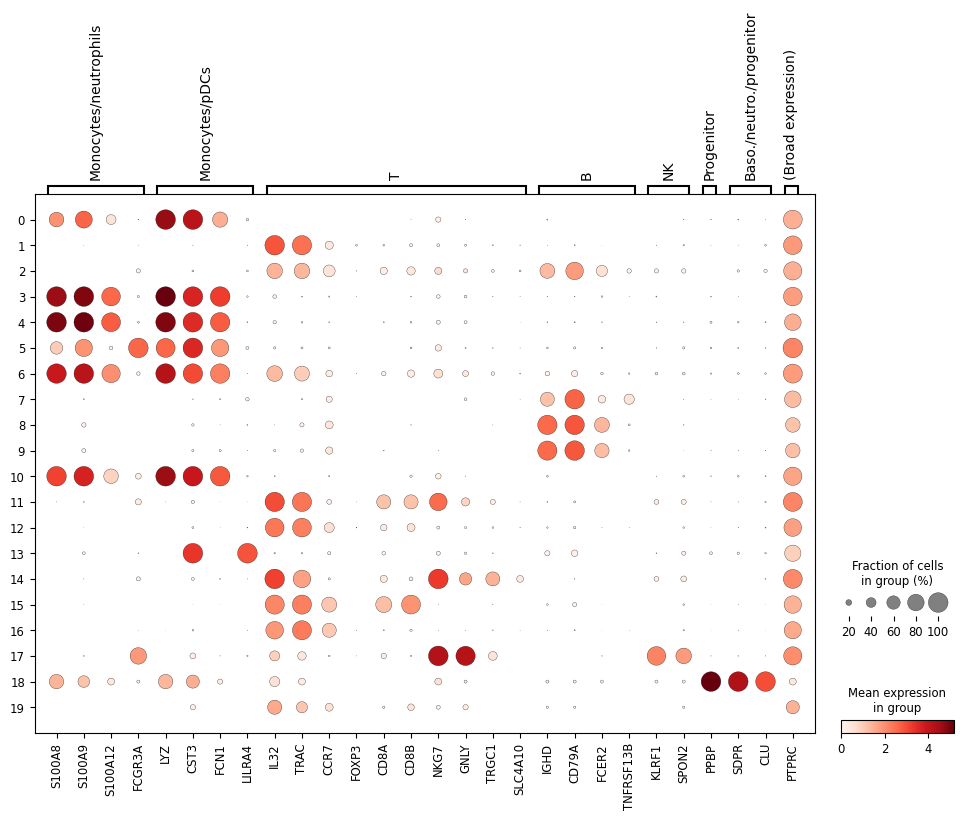

... storing 'broad_celltype' as categorical


------------------------------
DecontX Raw Data Dotplot


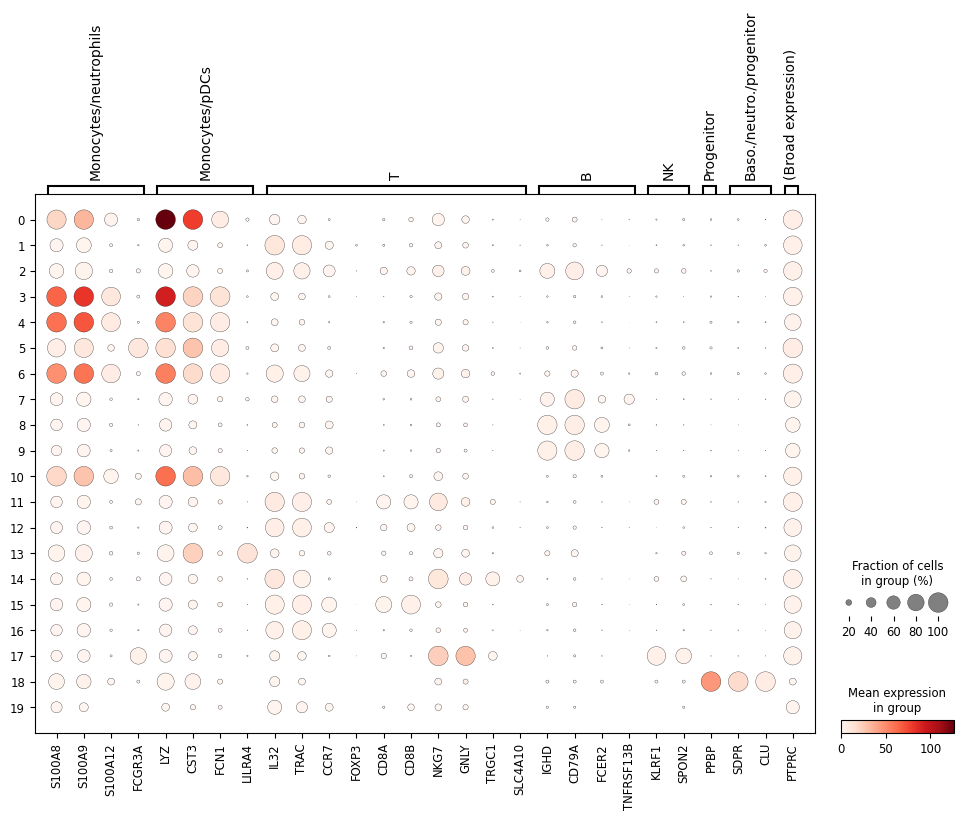

... storing 'broad_celltype' as categorical


------------------------------
DecontX Processed Data Dotplot


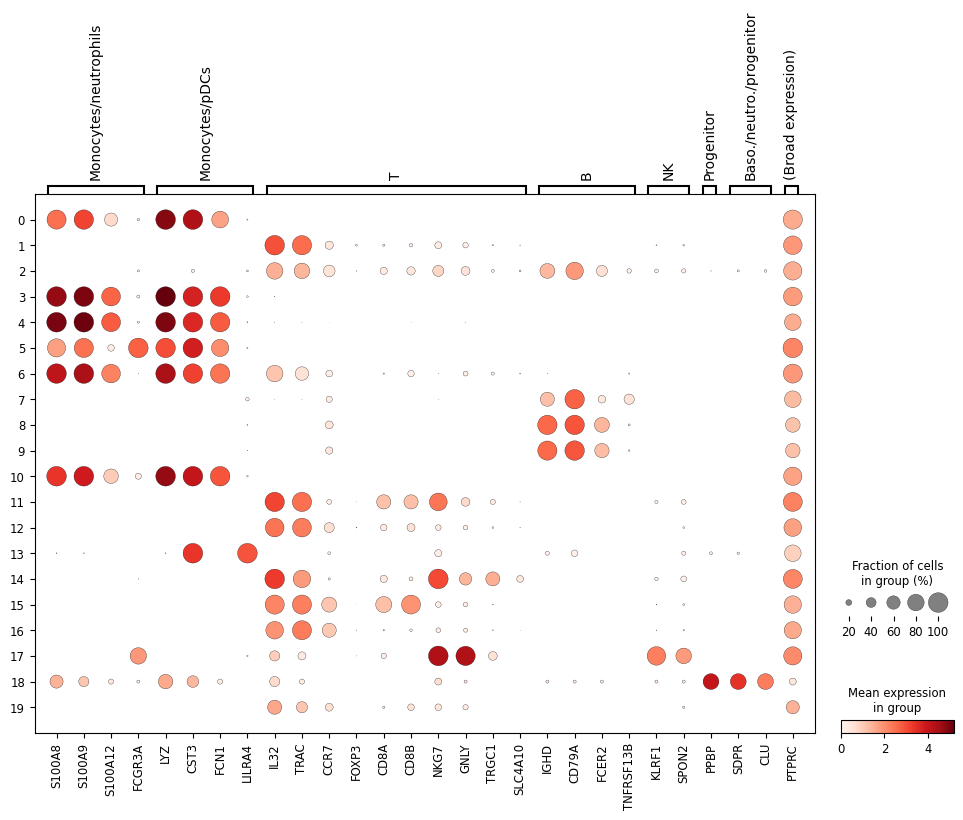

... storing 'broad_celltype' as categorical


------------------------------
scAR Raw Data Dotplot


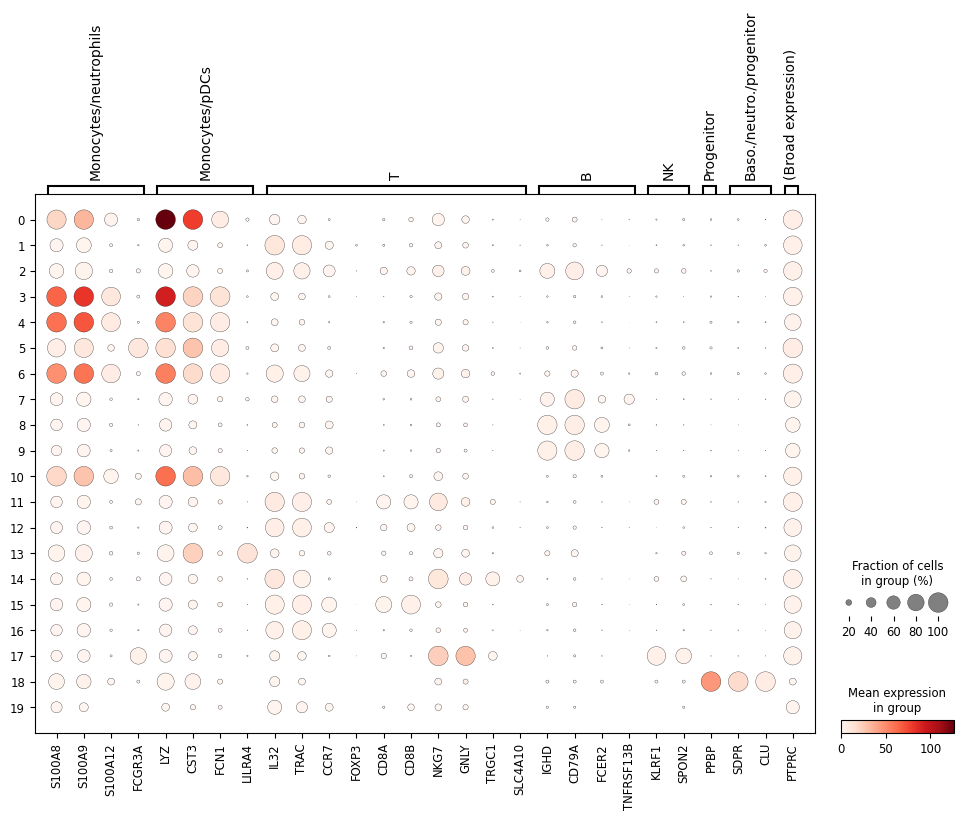

... storing 'broad_celltype' as categorical


------------------------------
scAR Processed Data Dotplot


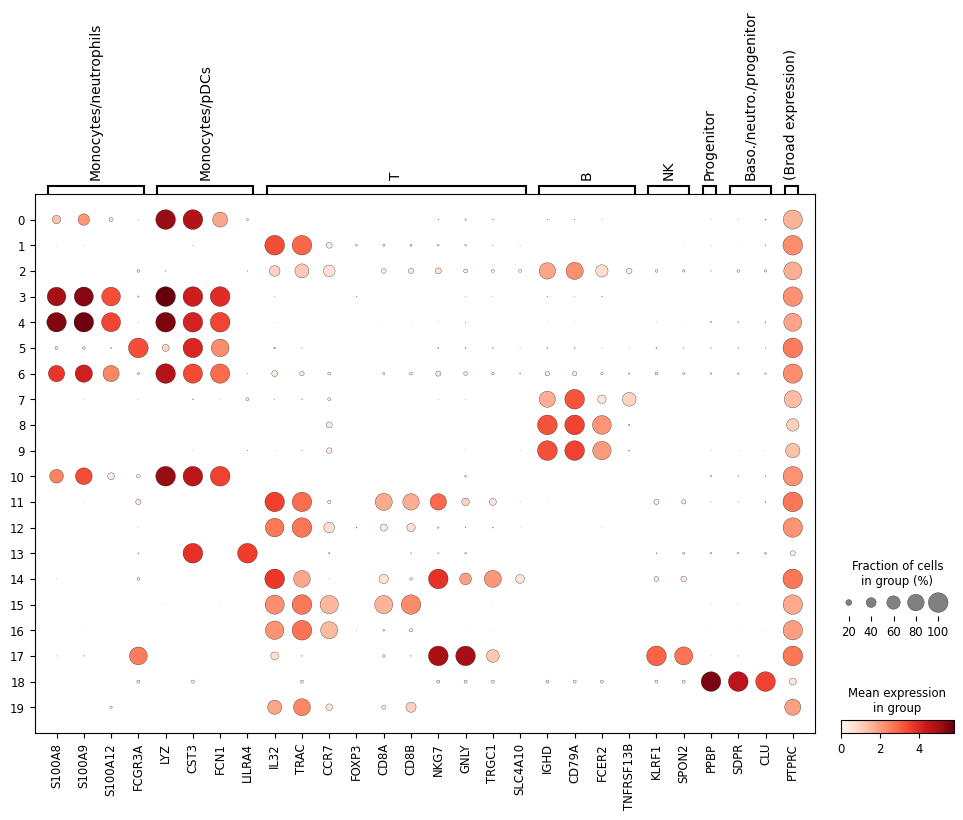

------------------------------


In [ ]:
adata_cellmender.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_cellmender.obs.index)
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender_with_cellbender_clusters.png"))

cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))

if adata_soupx:
    adata_soupx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_soupx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx_with_cellbender_clusters.png"))
if adata_decontx:
    adata_decontx.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_decontx.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx_with_cellbender_clusters.png"))
if adata_scar:
    adata_scar.obs["leiden_cellbender"] = adata_cellbender.obs["leiden"].reindex(adata_scar.obs.index)
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellbender", title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw_with_cellbender_clusters.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar_with_cellbender_clusters.png"))

## Bonus: runtime (on our machine)

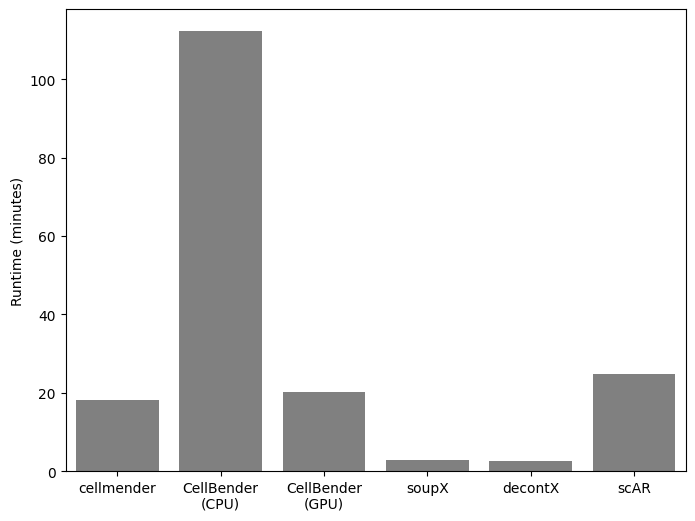

In [ ]:
runtimes = {
    "pbmc8k": {
        "cellmender": (18 + 8/60),  # 18 minutes, 8 seconds
        "CellBender\n(CPU)": (1*60 + 52 + 20/60),  # 1 hour, 52 minutes, 20 seconds
        "CellBender\n(GPU)": (20 + 17/60),  # 20 minutes, 17 seconds - NVIDIA RTX 3070
        "soupX": (2 + 43/60),  # 2 minutes, 43 seconds
        "decontX": (2 + 37/60),  # 2 minutes, 37 seconds
        "scAR": (24 + 52/60)  # 24 minutes, 52 seconds
    }
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(runtimes["pbmc8k"].keys()), y=list(runtimes["pbmc8k"].values()), color="gray")
plt.ylabel("Runtime (minutes)")
plt.savefig(os.path.join(out_dir, "runtime_comparison.png"))
plt.show()

## Bonus: Number of parameters in cellmender and CellBender

In [ ]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

17:01:20 - INFO - Number of parameters in the cellmender model: 344,982 (alpha_i: 8,381, beta: 1, gamma_type: 67,048, p_k: 269,552)


In [ ]:
cellbender_parameters = cm_utils.count_cellbender_parameters(cellbender_ckpt)
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")


=== Model Architecture (inferred from state_dict) ===
Total parameters: 31,758,725

encoder_z$$$network.0.layer.0.weight               | Shape: torch.Size([512, 15166]) | Params: 7,764,992
encoder_z$$$network.0.layer.0.bias                 | Shape: torch.Size([512])    | Params: 512
encoder_z$$$loc_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$loc_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_z$$$sig_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$sig_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_other$$$layer1.weight                      | Shape: torch.Size([512, 15170]) | Params: 7,767,040
encoder_other$$$layer1.bias                        | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.weight                  | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.bias   